# Agenda

End 2 end solution:

1.  Import the dataset

2.  Data understanding + schema validation

3.  Statistical summary of the dataset

4.  Data quality & missing value checks

5.  Data cleaning / Data imputation (inconsistencies, scaling)

6.  Outlier detection and removal (IQR / Clustering / Model-based)

7.  Multicollinearity checks - Correlation matrix / pairwise relationships

8.  Data imbalance check + handling

9.  Feature engineering - Synthetic features (ratios etc)

10. Feature encoding techniques

11. Feature selection (PCA, SHAP, RFE, etc.)

12. Visualization (EDA + target-based)

13. Train/Val/Test split + Stratified K-Fold

14. Model training & validation (multiple algorithms)

15. Model export to disk

16. Load model and predict on test data

# Customer Churn Prediction

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, recall_score, accuracy_score
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline


from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_curve, f1_score, accuracy_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [6]:
# ------------------------------------------------------------
# 1) Import the dataset
# ------------------------------------------------------------

df_raw = pd.read_csv('/Users/manojkumar_rajendran/Desktop/MR/Technology_Learning/TutorNotes/Data_Science/Classical_ML/dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [7]:
display(df_raw)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [8]:
# ------------------------------------------------------------
# 2) Data understanding (quick profile)
# ------------------------------------------------------------
print("=== SHAPE ===")
print(df_raw.shape)

print("\n=== COLUMNS & DTYPES ===")
print(df_raw.dtypes)

print("\n=== HEAD(5) ===")
display(df_raw.head())

print("\n=== MISSING VALUES (raw) ===") # NaN (Not a Number)
print(df_raw.isna().sum().sort_values(ascending=False))

print("\n=== SAMPLE UNIQUE COUNTS (top 20 columns by cardinality) ===")
uniq = df_raw.nunique().sort_values(ascending=False)
print(uniq.head(20))

=== SHAPE ===
(7043, 21)

=== COLUMNS & DTYPES ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

=== HEAD(5) ===


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



=== MISSING VALUES (raw) ===
customerID          0
DeviceProtection    0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
PaperlessBilling    0
Contract            0
StreamingMovies     0
StreamingTV         0
TechSupport         0
OnlineBackup        0
gender              0
OnlineSecurity      0
InternetService     0
MultipleLines       0
PhoneService        0
tenure              0
Dependents          0
Partner             0
SeniorCitizen       0
Churn               0
dtype: int64

=== SAMPLE UNIQUE COUNTS (top 20 columns by cardinality) ===
customerID          7043
TotalCharges        6531
MonthlyCharges      1585
tenure                73
PaymentMethod          4
DeviceProtection       3
Contract               3
StreamingMovies        3
StreamingTV            3
TechSupport            3
OnlineBackup           3
OnlineSecurity         3
InternetService        3
MultipleLines          3
gender                 2
PhoneService           2
PaperlessBilling       2
Dependen

In [9]:
df = df_raw.copy()

In [10]:
# ------------------------------------------------------------
# 3) Statistical summaries
# ------------------------------------------------------------
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]

print("\n=== NUMERICAL SUMMARY ===")
display(df[num_cols].describe().T)

print("\n=== CATEGORICAL SUMMARY (top values) ===")
for c in cat_cols:
    vc = df[c].value_counts(dropna=False).head(10)
    print(f"\n[{c}]")
    print(vc)


=== NUMERICAL SUMMARY ===


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75



=== CATEGORICAL SUMMARY (top values) ===

[customerID]
customerID
7590-VHVEG    1
3791-LGQCY    1
6008-NAIXK    1
5956-YHHRX    1
5365-LLFYV    1
5855-EIBDE    1
8166-ZZTFS    1
0129-KPTWJ    1
9128-CPXKI    1
9509-MPYOD    1
Name: count, dtype: int64

[gender]
gender
Male      3555
Female    3488
Name: count, dtype: int64

[Partner]
Partner
No     3641
Yes    3402
Name: count, dtype: int64

[Dependents]
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

[PhoneService]
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

[MultipleLines]
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

[InternetService]
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

[OnlineSecurity]
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

[OnlineBackup]
OnlineBackup
No                     308

In [11]:
#### 4) Duplicates
dupes = df.duplicated().sum()
print(f"\nDuplicate rows: {dupes}")

# Unique check for identifiers
if "customerID" in df.columns:
    print("\nUnique customerID check:")
    print("Duplicates in ID:", df["customerID"].duplicated().sum())



Duplicate rows: 0

Unique customerID check:
Duplicates in ID: 0


In [12]:
#### 5) Zero values for numeric columns (potential issue)
num_cols = df.select_dtypes(include=[np.number]).columns
zero_counts = (df[num_cols] == 0).sum()
print("\nZero-value check (possible placeholders):")
print(zero_counts)


Zero-value check (possible placeholders):
SeniorCitizen     5901
tenure              11
MonthlyCharges       0
dtype: int64


In [13]:
# -------------------------------
# OPTIONAL : Missing Value Summary Table
# -------------------------------
missing = df.isna().sum().to_frame(name="missing_count")
missing["missing_percent"] = (missing["missing_count"] / len(df)) * 100
print("=== Missing Value Summary ===")
display(missing.sort_values("missing_percent", ascending=False))


=== Missing Value Summary ===


,missing_count,missing_percent
customerID,0,0.0
DeviceProtection,0,0.0
TotalCharges,0,0.0
MonthlyCharges,0,0.0
PaymentMethod,0,0.0
PaperlessBilling,0,0.0
Contract,0,0.0
StreamingMovies,0,0.0
StreamingTV,0,0.0
TechSupport,0,0.0


In [14]:
### 6) Check for unexpected categorical values
cat_cols = df.select_dtypes(include=["object"]).columns
for col in cat_cols:
    bad_vals = df[col].isin(["?", "Unknown", " "])
    display(df[bad_vals])
    print(f"Unexpected values found in {col}: {bad_vals.sum()}")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


Unexpected values found in customerID: 0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


Unexpected values found in gender: 0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


...

Unexpected values found in PaymentMethod: 0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


Unexpected values found in TotalCharges: 11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


Unexpected values found in Churn: 0


In [15]:
#### 7) Data imputation

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"].replace(" ", np.nan), errors="coerce"
)

print("\nNon-numeric TotalCharges converted to NaN:")
print(df["TotalCharges"].isna().sum())

# --------------------------------
# Logical Consistency Fixes
#    If no PhoneService, MultipleLines must be "No"
# --------------------------------
mask_phone = df["PhoneService"] == "No"
df.loc[mask_phone, "MultipleLines"] = "No"

#    If no internet service -> set all dependent internet services to "No internet service"
internet_features = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]
mask_no_internet = df["InternetService"] == "No"
for col in internet_features:
    df.loc[mask_no_internet, col] = "No internet service"


# Handle brand new customers
mask_tenure_zero = df["tenure"] == 0
df[mask_tenure_zero]
df.loc[mask_tenure_zero, "TotalCharges"] = 0


print(df["TotalCharges"].isna().sum())


Non-numeric TotalCharges converted to NaN:
11
0


In [16]:
### 8) Outlier detection and removal

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

def iqr_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask = (df[col] < lower) | (df[col] > upper)
    return mask, lower, upper


print("🔍 IQR Outlier Detection Summary\n")
outlier_indices = set()

for col in num_cols:
    mask, lower, upper = iqr_outliers(df, col)
    n_outliers = mask.sum()
    outlier_indices.update(df[mask].index)
    
    print(f"{col}:")
    print(f"  Q1={df[col].quantile(0.25):.2f}, Q3={df[col].quantile(0.75):.2f}")
    print(f"  IQR={df[col].quantile(0.75) - df[col].quantile(0.25):.2f}")
    print(f"  Lower bound={lower:.2f}, Upper bound={upper:.2f}")
    print(f"  Outliers: {n_outliers} ({(n_outliers/len(df))*100:.2f}%)\n")


print(f"🔎 Total unique outlier rows flagged: {len(outlier_indices)} "
      f"({(len(outlier_indices)/len(df))*100:.2f}%)")

🔍 IQR Outlier Detection Summary

tenure:
  Q1=9.00, Q3=55.00
  IQR=46.00
  Lower bound=-60.00, Upper bound=124.00
  Outliers: 0 (0.00%)

MonthlyCharges:
  Q1=35.50, Q3=89.85
  IQR=54.35
  Lower bound=-46.02, Upper bound=171.38
  Outliers: 0 (0.00%)

TotalCharges:
  Q1=398.55, Q3=3786.60
  IQR=3388.05
  Lower bound=-4683.52, Upper bound=8868.67
  Outliers: 0 (0.00%)

🔎 Total unique outlier rows flagged: 0 (0.00%)


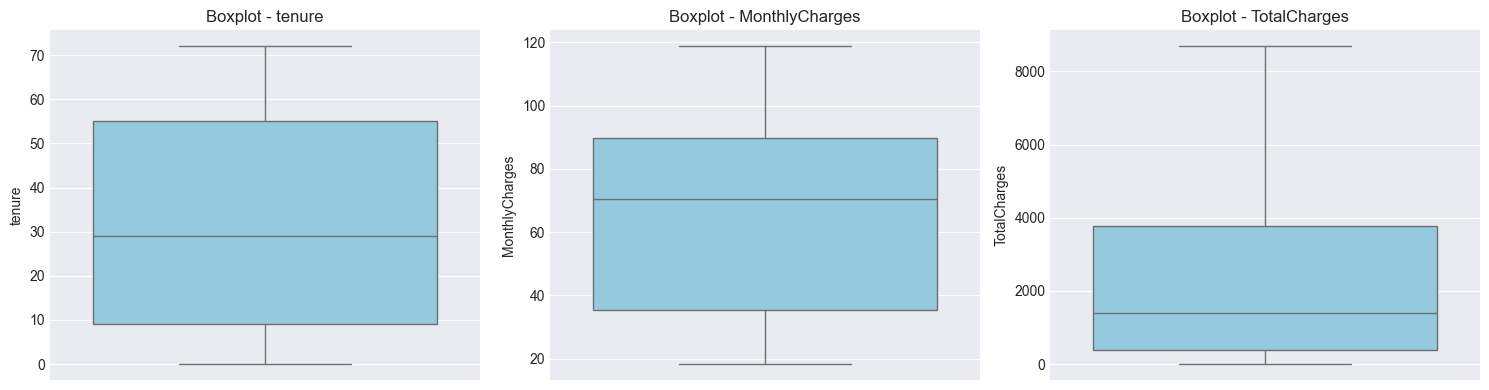

In [17]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axs[i], color="skyblue")
    axs[i].set_title(f"Boxplot - {col}")
plt.tight_layout()
plt.show()

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.247900,0.826178
MonthlyCharges,0.247900,1.000000,0.651174
TotalCharges,0.826178,0.651174,1.000000


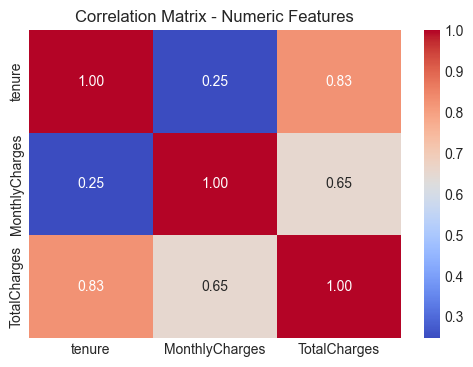

In [18]:
### 8) Correlation matrix

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

corr = df[num_cols].corr()

display(corr)

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix - Numeric Features")
plt.show()

MonthlyCharges and TotalCharges → strong positive correlation

Tenure also correlated with TotalCharges

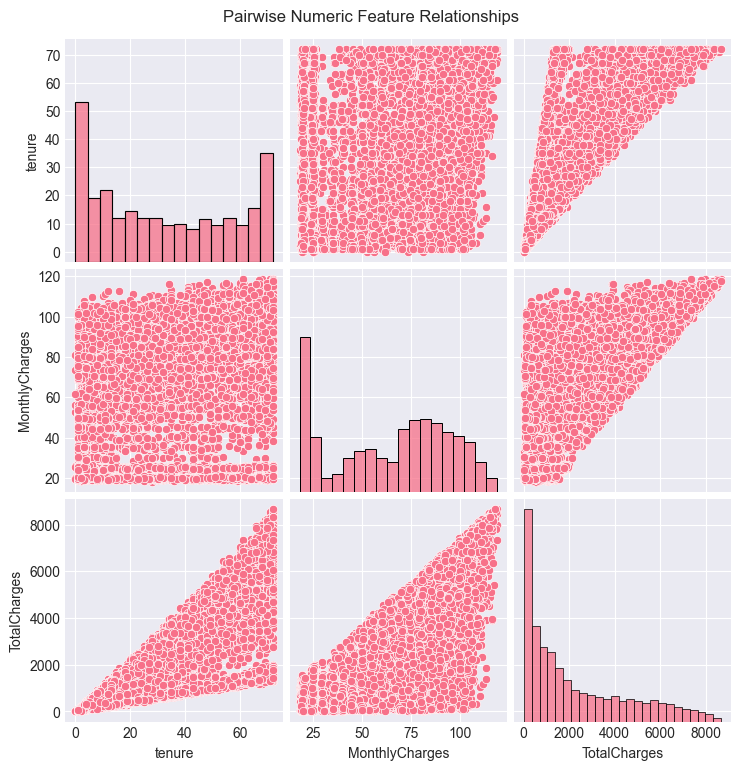

In [19]:
sns.pairplot(df[num_cols])
plt.suptitle("Pairwise Numeric Feature Relationships", y=1.02)
plt.show()

What to Do With Correlated Features?

Option A — Keep Both

If using tree-based models (Random Forest, XGBoost, CatBoost): They can naturally handle correlated features.

Option B — Remove One

If using Logistic Regression or Linear models: Drop TotalCharges (because it is derived from tenure & monthly charges)

Option C — Replace With Engineered Feature



In [20]:
### 9) Synthetic features

df["AvgMonthlySpend"] = df["TotalCharges"] / df["tenure"]
df["AvgMonthlySpend"] = df["AvgMonthlySpend"].fillna(df["MonthlyCharges"])

service_cols = [
    "PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"
]
df["ServicesCount"] = df[service_cols].apply(lambda row: sum(row == "Yes"), axis=1)

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 60, df["tenure"].max()],
    labels=["0-12m", "12-24m", "24-48m", "48-60m", "60m+"]
)



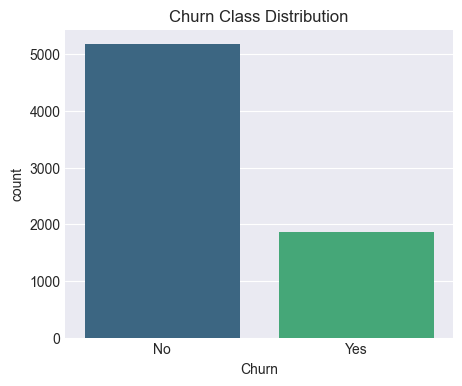

Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


In [21]:
### 10) - EDA using Visualization

# 10.2 - Churn Distribution

plt.figure(figsize=(5,4))
sns.countplot(data=df, x="Churn", palette="viridis")
plt.title("Churn Class Distribution")
plt.show()

print(df["Churn"].value_counts(normalize=True).round(3))

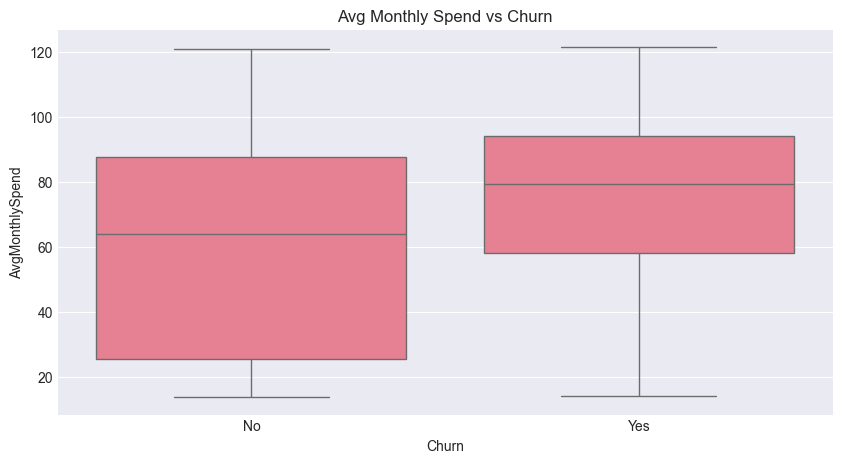

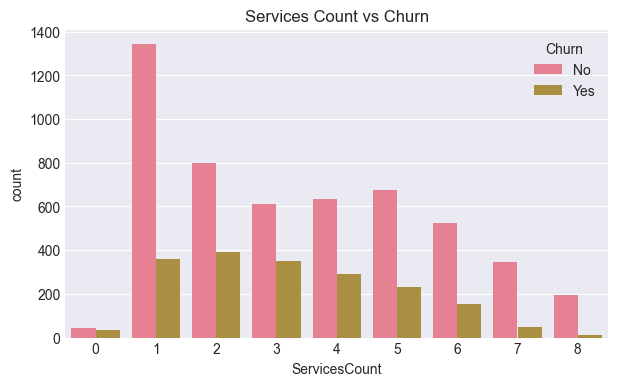

In [22]:
# 10.2 - how the new variables are distributed against Churn

plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="Churn", y="AvgMonthlySpend")
plt.title("Avg Monthly Spend vs Churn")
plt.show()

plt.figure(figsize=(7,4))
sns.countplot(data=df, x="ServicesCount", hue="Churn")
plt.title("Services Count vs Churn")
plt.show()

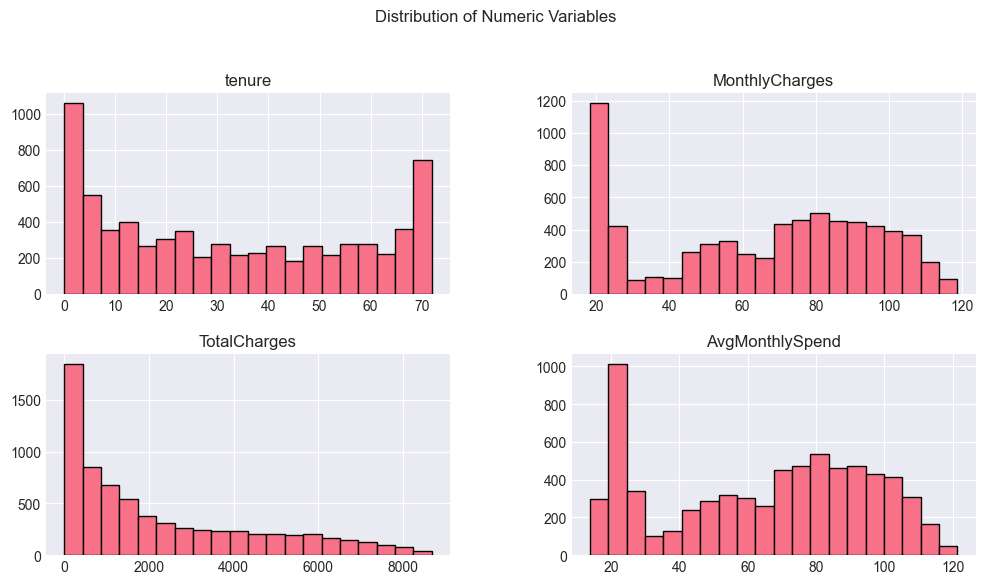

In [23]:
# 10.3 - Distribution of Key Numeric Variables

num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "AvgMonthlySpend"]

df[num_cols].hist(figsize=(12,6), bins=20, edgecolor='black')
plt.suptitle("Distribution of Numeric Variables", y=1.02)
plt.show()

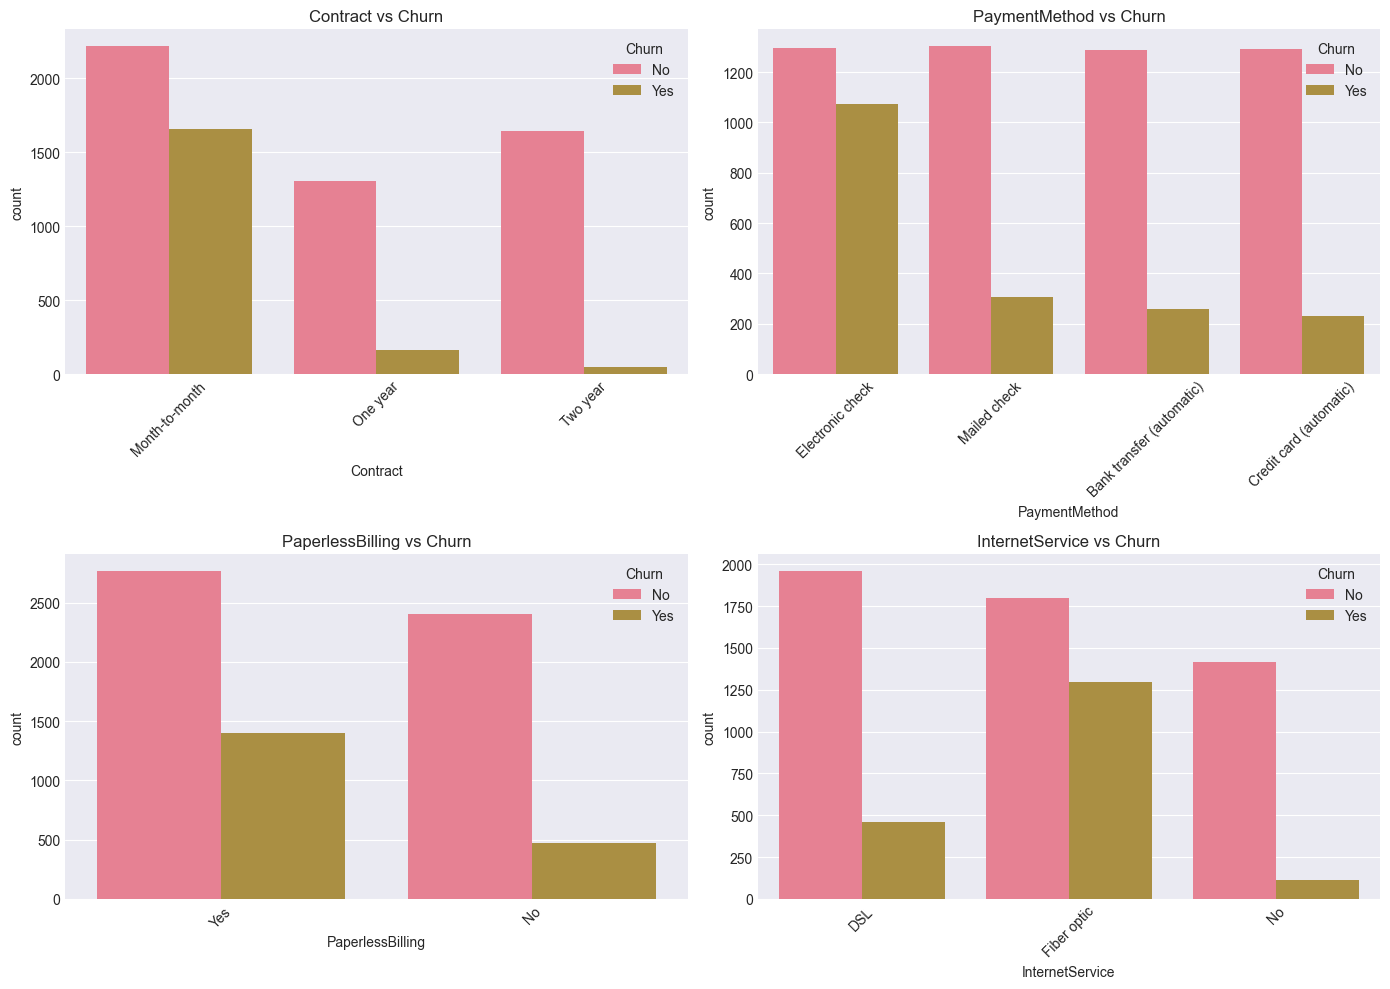

In [24]:
# 10.4 - Categorical vs Churn (Boxplots)

cat_cols = ["Contract", "PaymentMethod", "PaperlessBilling", "InternetService"]

plt.figure(figsize=(14,10))
for i, col in enumerate(cat_cols):
    plt.subplot(2,2,i+1)
    sns.countplot(data=df, x=col, hue="Churn")
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Churn")
plt.tight_layout()
plt.show()

In [25]:
### 11) Train Test Split

from sklearn.model_selection import train_test_split

# Our Data from previous steps
X = df.drop(["customerID", "Churn"], axis=1)
y = df["Churn"].map({"No": 0, "Yes": 1})

# First split: Train + Temp (Val+Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,     # 70% train, 30% temporary set
    stratify=y,
    random_state=42
)

# Second split: Validation + Test (from X_temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,     # splits 30% into 15% val + 15% test
    stratify=y_temp,
    random_state=42
)

Data Leakage - model tries to get a sneak peek into the future unseen data


Training Set Distribution:
Churn
0    73.5
1    26.5 %


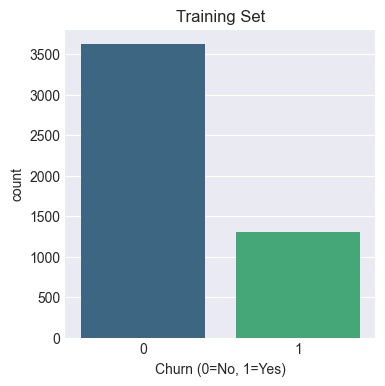


Validation Set Distribution:
Churn
0    73.5
1    26.5 %


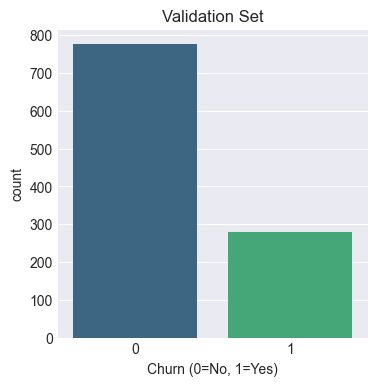


Test Set Distribution:
Churn
0    73.4
1    26.6 %


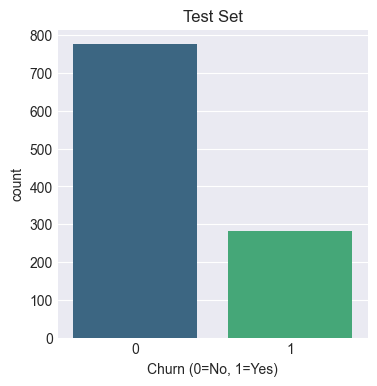

In [26]:
### 12) Data imbalance checks

def plot_class_balance(y, title):
    counts = y.value_counts(normalize=True).round(3) * 100
    print(f"\n{title} Distribution:")
    print(counts.to_string(), "%")

    plt.figure(figsize=(4,4))
    sns.countplot(x=y, palette="viridis")
    plt.title(title)
    plt.xlabel("Churn (0=No, 1=Yes)")
    plt.show()

plot_class_balance(y_train, "Training Set")
plot_class_balance(y_val, "Validation Set")
plot_class_balance(y_test, "Test Set")

In [27]:
### 13) Apply SMOTE

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("\nAfter SMOTE:", y_train_res.value_counts())

ValueError: Input contains NaN

In [28]:
print(X_train.isna().sum().sort_values(ascending=False))  # columns with NaNs

TenureGroup         7
SeniorCitizen       0
ServicesCount       0
AvgMonthlySpend     0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
PaperlessBilling    0
Contract            0
StreamingMovies     0
StreamingTV         0
gender              0
DeviceProtection    0
OnlineBackup        0
OnlineSecurity      0
InternetService     0
MultipleLines       0
PhoneService        0
tenure              0
Dependents          0
Partner             0
TechSupport         0
dtype: int64


In [30]:
display(X_train[X_train['TenureGroup'].isna()])

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,AvgMonthlySpend,ServicesCount,TenureGroup
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,...,Yes,No,Two year,No,Mailed check,73.35,0.0,73.35,6,NaN
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,Two year,No,Mailed check,25.35,0.0,25.35,2,NaN
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,Two year,No,Mailed check,20.00,0.0,20.00,1,NaN
488,Female,0,Yes,Yes,0,No,No,DSL,Yes,No,...,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,0.0,52.55,4,NaN
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,Two year,No,Mailed check,25.75,0.0,25.75,2,NaN
6754,Male,0,No,Yes,0,Yes,Yes,DSL,Yes,Yes,...,No,No,Two year,Yes,Bank transfer (automatic),61.90,0.0,61.90,5,NaN
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,Two year,No,Mailed check,19.85,0.0,19.85,1,NaN


In [31]:
# Recreate TenureGroup from tenure column
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 60, df["tenure"].max()],
    labels=["0-12m", "12-24m", "24-48m", "48-60m", "60m+"],
    include_lowest=True
)

# df["TenureGroup"] = df["TenureGroup"].fillna(df["TenureGroup"].mode()[0])

display(df)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,ServicesCount,TenureGroup
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,29.850000,1,0-12m
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,55.573529,3,24-48m
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,54.075000,3,0-12m
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,40.905556,3,24-48m
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,75.825000,1,0-12m
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,One year,Yes,Mailed check,84.80,1990.50,No,82.937500,7,12-24m
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,102.262500,6,60m+
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No,DSL,Yes,...,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,31.495455,1,0-12m
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,76.650000,2,0-12m


In [32]:
# Redoing train-test split

X = df.drop(["customerID", "Churn"], axis=1)
y = df["Churn"].map({"No": 0, "Yes": 1})

# First split: Train + Temp (Val+Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,     # 70% train, 30% temporary set
    stratify=y,
    random_state=42
)

# Second split: Validation + Test (from X_temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,     # splits 30% into 15% val + 15% test
    stratify=y_temp,
    random_state=42
)

In [33]:
# Rechecking the NaN values

print(X_train.isna().sum().sort_values(ascending=False))  # columns with NaNs

gender              0
SeniorCitizen       0
ServicesCount       0
AvgMonthlySpend     0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
PaperlessBilling    0
Contract            0
StreamingMovies     0
StreamingTV         0
TechSupport         0
DeviceProtection    0
OnlineBackup        0
OnlineSecurity      0
InternetService     0
MultipleLines       0
PhoneService        0
tenure              0
Dependents          0
Partner             0
TenureGroup         0
dtype: int64


In [34]:
# Now let's apply SMOTE again

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("\nAfter SMOTE:", y_train_res.value_counts())

ValueError: could not convert string to float: 'Female'

In [36]:
# Feature encoding - Let's convert text to numbers

from sklearn.preprocessing import OneHotEncoder

cat_cols = [c for c in X_train.columns if X_train[c].dtype == 'object']
num_cols = [c for c in X_train.columns if c not in cat_cols]

# OneHot-Encoding (only on training)
ohe = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
X_train_ohe = ohe.fit_transform(X_train[cat_cols])

# Combine numeric + encoded categorical
X_train_ready = np.hstack([X_train[num_cols].values, X_train_ohe])

# Get the encoded feature names from the OHE
ohe_features = ohe.get_feature_names_out(cat_cols)

display(ohe_features)

# Combine numeric + encoded feature names
all_feature_names = list(num_cols) + list(ohe_features)

# Convert to DataFrame with column names
X_train_ready_df = pd.DataFrame(X_train_ready, columns=all_feature_names)

display(X_train_ready_df)

array(['gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No internet service',
       'DeviceProtection_Yes', 'TechSupport_No internet service',
       'TechSupport_Yes', 'StreamingTV_No internet service',
       'StreamingTV_Yes', 'StreamingMovies_No internet service',
       'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year',
       'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype=object)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,AvgMonthlySpend,ServicesCount,TenureGroup,gender_Male,Partner_Yes,Dependents_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,5,80.2,384.25,76.85,2,0-12m,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1,3,86.85,220.95,73.65,3,0-12m,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0,3,75.15,216.75,72.25,2,0-12m,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3,0,60,80.55,4847.05,80.784167,6,48-60m,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
4,0,12,98.9,1120.95,93.4125,5,0-12m,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4925,0,63,104.5,6590.8,104.615873,7,60m+,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4926,0,1,51.25,51.25,51.25,2,0-12m,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4927,0,71,109.25,7707.7,108.559155,7,60m+,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
4928,0,24,20.4,482.8,20.116667,1,12-24m,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


<b> Why drop="first"? </b>

Example - gender: Male, Female

OneHotEncoder generates:

Male → [1,0]
Female → [0,1]

But that’s redundant, because:
If not Male → must be Female.

So we drop the first category → only 1 column:

Male → 1
Female → 0

Less number of features

<b> Why handle_unknown="ignore"? </b>

Example - Model trained on [Month-to-month, Two year]

In Validation set, we get new value : One year

Without this flag → ValueError
With ignore → safely encoded as all zeros

Robust against new categories

Helps avoid production failures

In [37]:
display(X_train_ready)

array([[0, 5, 80.2, ..., 0.0, 1.0, 0.0],
       [1, 3, 86.85, ..., 0.0, 1.0, 0.0],
       [0, 3, 75.15, ..., 1.0, 0.0, 0.0],
       ...,
       [0, 71, 109.25, ..., 0.0, 1.0, 0.0],
       [0, 24, 20.4, ..., 1.0, 0.0, 0.0],
       [0, 6, 20.65, ..., 0.0, 0.0, 1.0]], shape=(4930, 32), dtype=object)

In [38]:
# Now let's apply SMOTE again

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train_ready, y_train)

print("Before SMOTE:", y_train.value_counts())
print("\nAfter SMOTE:", y_train_res.value_counts())

ValueError: could not convert string to float: '0-12m'

In [39]:
"TenureGroup" in num_cols

True

In [40]:
if "TenureGroup" in num_cols:
    num_cols.remove("TenureGroup")
    cat_cols.append("TenureGroup")

In [41]:
# Rerun OneHot Encoding

ohe = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
X_train_ohe = ohe.fit_transform(X_train[cat_cols])

X_train_ready = np.hstack([X_train[num_cols].values, X_train_ohe])

# Convert to DataFrame
ohe_features = ohe.get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(ohe_features)

X_train_ready_df = pd.DataFrame(X_train_ready, columns=all_feature_names)

display(X_train_ready_df)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,AvgMonthlySpend,ServicesCount,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_12-24m,TenureGroup_24-48m,TenureGroup_48-60m,TenureGroup_60m+
0,0.0,5.0,80.20,384.25,76.850000,2.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,1.0,3.0,86.85,220.95,73.650000,3.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,3.0,75.15,216.75,72.250000,2.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,60.0,80.55,4847.05,80.784167,6.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,12.0,98.90,1120.95,93.412500,5.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4925,0.0,63.0,104.50,6590.80,104.615873,7.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4926,0.0,1.0,51.25,51.25,51.250000,2.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4927,0.0,71.0,109.25,7707.70,108.559155,7.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4928,0.0,24.0,20.40,482.80,20.116667,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [42]:
# Now let's apply SMOTE again

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train_ready_df, y_train)

print("Before SMOTE:", y_train.value_counts())
print("\nAfter SMOTE:", y_train_res.value_counts())

Before SMOTE: Churn
0    3622
1    1308
Name: count, dtype: int64

After SMOTE: Churn
0    3622
1    3622
Name: count, dtype: int64


In [43]:
display(X_train_res.dtypes)

SeniorCitizen                            float64
tenure                                   float64
MonthlyCharges                           float64
TotalCharges                             float64
AvgMonthlySpend                          float64
ServicesCount                            float64
gender_Male                              float64
Partner_Yes                              float64
Dependents_Yes                           float64
PhoneService_Yes                         float64
MultipleLines_Yes                        float64
InternetService_Fiber optic              float64
InternetService_No                       float64
OnlineSecurity_No internet service       float64
OnlineSecurity_Yes                       float64
OnlineBackup_No internet service         float64
OnlineBackup_Yes                         float64
DeviceProtection_No internet service     float64
DeviceProtection_Yes                     float64
TechSupport_No internet service          float64
TechSupport_Yes     

In [44]:
# 14 -  Model training & validation (multiple algorithms)

# On dataset before applying SMOTE

# Models to evaluate
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
}

results = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\n🔹 Training {name}...")
    
    # Cross-validated predictions on TRAIN set
    y_pred = cross_val_predict(model, X_train_ready_df, y_train, cv=skf, method="predict")
    y_proba = cross_val_predict(model, X_train_ready_df, y_train, cv=skf, method="predict_proba")[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_train, y_pred),
        "Recall": recall_score(y_train, y_pred),
        "F1": f1_score(y_train, y_pred),
        "ROC-AUC": roc_auc_score(y_train, y_proba),
        "PR-AUC": average_precision_score(y_train, y_proba)
    })

results_df = pd.DataFrame(results)
display(results_df.sort_values("PR-AUC", ascending=False))


🔹 Training LogisticRegression...

🔹 Training RandomForest...


,Model,Accuracy,Recall,F1,ROC-AUC,PR-AUC
0,LogisticRegression,0.747667,0.797401,0.626426,0.843819,0.660128
1,RandomForest,0.795740,0.482416,0.556192,0.832210,0.635477


What cross_val_predict() does ?

1.  Split training data into K folds

2.  Train model K times, each time on K-1 folds

3.  Predict on the 1 remaining fold

4.  Collect all predictions across folds

In [45]:
# On dataset after applying SMOTE

# Models to evaluate
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
}

results = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\n🔹 Training {name}...")
    
    # Cross-validated predictions on TRAIN set
    y_pred = cross_val_predict(model, X_train_res, y_train_res, cv=skf, method="predict")
    y_proba = cross_val_predict(model, X_train_res, y_train_res, cv=skf, method="predict_proba")[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_train_res, y_pred),
        "Recall": recall_score(y_train_res, y_pred),
        "F1": f1_score(y_train_res, y_pred),
        "ROC-AUC": roc_auc_score(y_train_res, y_proba),
        "PR-AUC": average_precision_score(y_train_res, y_proba)
    })

results_df = pd.DataFrame(results)
display(results_df.sort_values("PR-AUC", ascending=False))


🔹 Training LogisticRegression...

🔹 Training RandomForest...


,Model,Accuracy,Recall,F1,ROC-AUC,PR-AUC
1,RandomForest,0.862783,0.839867,0.859565,0.937739,0.942233
0,LogisticRegression,0.768636,0.807289,0.777246,0.851947,0.831405


In [164]:
print(cat_cols)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']


In [46]:
# Now, let's test our learning on validation dataset

# --- Build VALIDATION features with the SAME encoder/columns ---
X_val_ohe = ohe.transform(X_val[cat_cols])  # do NOT fit here
X_val_ready = np.hstack([X_val[num_cols].values, X_val_ohe])

# Use the SAME column order as training
X_val_ready_df = pd.DataFrame(X_val_ready, columns=all_feature_names, index=X_val.index)

# --- Pick best model from CV table (by PR-AUC) and train it on SMOTE'd train ---
best_model_name = results_df.sort_values("PR-AUC", ascending=False)["Model"].iloc[0]
best_model = models[best_model_name]
print(f"\n🚀 Training best model on SMOTE’d training set: {best_model_name}")

best_model.fit(X_train_res, y_train_res)

# --- Evaluate on VALIDATION set (unmodified data) ---
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score, confusion_matrix, classification_report
)

y_val_pred  = best_model.predict(X_val_ready_df)
y_val_proba = best_model.predict_proba(X_val_ready_df)[:, 1]

print("\n📊 Validation Metrics")
print("ROC-AUC :", round(roc_auc_score(y_val, y_val_proba), 3))
print("PR-AUC  :", round(average_precision_score(y_val, y_val_proba), 3))
print("Recall  :", round(recall_score(y_val, y_val_pred), 3))
print("Precision:", round(precision_score(y_val, y_val_pred), 3))
print("F1      :", round(f1_score(y_val, y_val_pred), 3))

print("\nConfusion Matrix (Validation):")
print(confusion_matrix(y_val, y_val_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, digits=3))


🚀 Training best model on SMOTE’d training set: RandomForest

📊 Validation Metrics
ROC-AUC : 0.822
PR-AUC  : 0.597
Recall  : 0.546
Precision: 0.605
F1      : 0.574

Confusion Matrix (Validation):
[[676 100]
 [127 153]]

Classification Report:
              precision    recall  f1-score   support

           0      0.842     0.871     0.856       776
           1      0.605     0.546     0.574       280

    accuracy                          0.785      1056
   macro avg      0.723     0.709     0.715      1056
weighted avg      0.779     0.785     0.781      1056



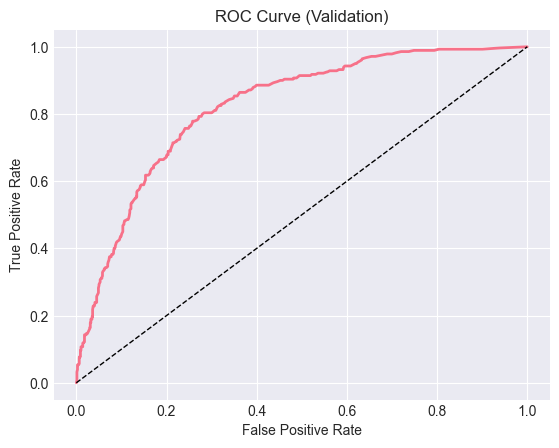

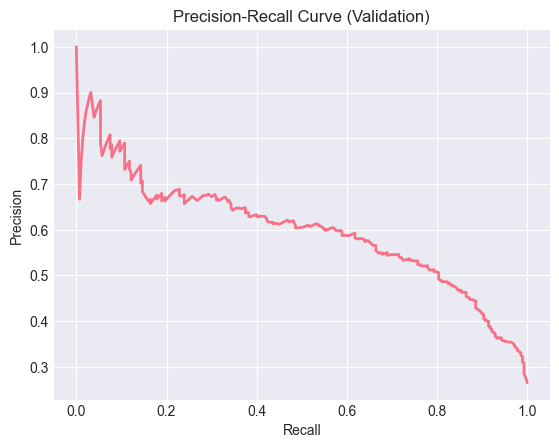

In [47]:
# ROC curve
fpr, tpr, _ = roc_curve(y_val, y_val_proba)
plt.figure()
plt.plot(fpr, tpr, lw=2)
plt.plot([0,1],[0,1], 'k--', lw=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Validation)")
plt.show()

# Precision-Recall curve
prec, rec, thr = precision_recall_curve(y_val, y_val_proba)
plt.figure()
plt.plot(rec, prec, lw=2)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Validation)")
plt.show()

The further the ROC curve bends toward the top-left corner, the better the model.

Closer to diagonal line = poor separation

Close to top-left = good performance



You cannot achieve high Recall and high Precision together.

There is a trade-off.

In [48]:
### 15) Serialize model to disk

import joblib
import os

os.makedirs("model_artifacts", exist_ok=True)

# Save trained model (Random Forest)
joblib.dump(best_model, "model_artifacts/churn_model.pkl")

# Save OneHotEncoder fitted on train
joblib.dump(ohe, "model_artifacts/onehot_encoder.pkl")

# Save column lists used in encoding
joblib.dump(cat_cols, "model_artifacts/categorical_columns.pkl")
joblib.dump(num_cols, "model_artifacts/numeric_columns.pkl")

# Save final feature names after encoding
joblib.dump(all_feature_names, "model_artifacts/feature_names.pkl")

print("✅ Model + Encoder successfully serialized to /model_artifacts/")

✅ Model + Encoder successfully serialized to /model_artifacts/


In [49]:
#### 16 - Load model and predict unseen data

# Load model + encoder
loaded_model = joblib.load("model_artifacts/churn_model.pkl")
loaded_ohe    = joblib.load("model_artifacts/onehot_encoder.pkl")
loaded_num    = joblib.load("model_artifacts/numeric_columns.pkl")
loaded_cat    = joblib.load("model_artifacts/categorical_columns.pkl")
loaded_feats  = joblib.load("model_artifacts/feature_names.pkl")

print("✅ Loaded everything successfully!")

✅ Loaded everything successfully!


In [50]:
# Transform categorical columns in test set using the SAME encoder (do NOT fit!)
X_test_ohe = ohe.transform(X_test[cat_cols])

# Reassemble full test feature matrix
X_test_ready = np.hstack([X_test[num_cols].values, X_test_ohe])

# Create DataFrame
X_test_ready_df = pd.DataFrame(
    X_test_ready,
    columns=all_feature_names,
    index=X_test.index
)

# Align with training feature set (handles any missing dummy columns)
X_test_ready_df = X_test_ready_df.reindex(columns=all_feature_names, fill_value=0)

In [51]:
# Predict churn classes
y_test_pred = loaded_model.predict(X_test_ready_df)

# Predict churn probability (positive class only)
y_test_proba = loaded_model.predict_proba(X_test_ready_df)[:, 1]

# Convert 0/1 to Yes/No strings
pred_labels = ["Yes" if p == 1 else "No" for p in y_test_pred]

In [53]:
# First, build prediction table as before
pred_results = pd.DataFrame({
    "Churn Prediction": pred_labels,
    "Churn Probability": y_test_proba.round(3)
}, index=X_test.index)

# Then concatenate X_test features for full insight
pred_full_df = pd.concat([X_test.reset_index(drop=True), pred_results.reset_index(drop=True)], axis=1)

# Display first rows
print("🔮 Test Predictions with Original Features Included:")
display(pred_full_df)

🔮 Test Predictions with Original Features Included:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,AvgMonthlySpend,ServicesCount,TenureGroup,Churn Prediction,Churn Probability
0,Male,1,No,No,17,Yes,No,DSL,No,No,...,Month-to-month,Yes,Electronic check,45.05,770.60,45.329412,1,12-24m,Yes,0.547
1,Male,0,Yes,No,43,Yes,No,DSL,No,No,...,One year,Yes,Mailed check,56.35,2391.15,55.608140,2,24-48m,No,0.233
2,Female,0,Yes,Yes,72,Yes,Yes,DSL,No,No,...,Two year,Yes,Bank transfer (automatic),76.80,5468.45,75.950694,5,60m+,No,0.133
3,Male,0,No,No,54,Yes,No,Fiber optic,Yes,No,...,Month-to-month,No,Mailed check,89.80,4667.00,86.425926,4,48-60m,No,0.220
4,Male,0,Yes,Yes,63,No,No,DSL,No,Yes,...,Two year,No,Bank transfer (automatic),39.35,2395.05,38.016667,3,60m+,No,0.037
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1052,Female,0,No,No,20,Yes,Yes,Fiber optic,Yes,No,...,Month-to-month,Yes,Bank transfer (automatic),89.10,1879.25,93.962500,4,12-24m,Yes,0.540
1053,Male,0,No,No,10,Yes,No,No,No internet service,No internet service,...,Month-to-month,No,Electronic check,20.00,185.40,18.540000,1,0-12m,No,0.163
1054,Female,0,No,No,15,Yes,Yes,DSL,No,No,...,Month-to-month,Yes,Mailed check,48.80,720.10,48.006667,2,12-24m,No,0.317
1055,Female,0,No,No,62,Yes,No,DSL,Yes,No,...,Two year,Yes,Mailed check,65.10,3846.75,62.044355,4,60m+,No,0.013


In [54]:
pred_full_df.to_csv("model_artifacts/churn_predictions_test.csv", index=False)
print("📁 Saved to model_artifacts/churn_predictions_test.csv")

📁 Saved to model_artifacts/churn_predictions_test.csv


In [55]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    recall_score, precision_score, f1_score,
    confusion_matrix, classification_report
)

print("\n📊 Final Test Metrics:")
print("ROC-AUC :", round(roc_auc_score(y_test, y_test_proba), 3))
print("PR-AUC  :", round(average_precision_score(y_test, y_test_proba), 3))
print("Recall  :", round(recall_score(y_test, y_test_pred), 3))
print("Precision:", round(precision_score(y_test, y_test_pred), 3))
print("F1      :", round(f1_score(y_test, y_test_pred), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, digits=3))


📊 Final Test Metrics:
ROC-AUC : 0.823
PR-AUC  : 0.627
Recall  : 0.498
Precision: 0.619
F1      : 0.552

Confusion Matrix:
[[690  86]
 [141 140]]

Classification Report:
              precision    recall  f1-score   support

           0      0.830     0.889     0.859       776
           1      0.619     0.498     0.552       281

    accuracy                          0.785      1057
   macro avg      0.725     0.694     0.706      1057
weighted avg      0.774     0.785     0.777      1057



The positive class here is 1 → Churners . 0 is the negative class.

Recall for churners (class 1) = 0.498 → The model misses ~50% of actual churners, meaning many customers who will leave are not being flagged.

Precision for churners = 0.619 → When the model predicts churn, it’s right only ~62% of the time, so retention offers may go to many non-churners.

The model currently favors predicting non-churners, resulting in many missed churn risks, so recall must be improved before deployment.

Action items:

Tune threshold for better recall

Optimize hyperparameters with GridSearchCV

Apply Boosting algorithms